In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from keras import Sequential
from keras.callbacks import EarlyStopping, TerminateOnNaN
from keras.layers import Dense, Dropout, Embedding, LSTM
from keras.utils import pad_sequences

# Kept for compatibility with the existing trained tokenizer.
from tensorflow.keras.preprocessing.text import Tokenizer  # type: ignore

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "diversevul_stratified_10000.csv"
)

print("LSTM development environment ready.")
print("TensorFlow version:", tf.__version__)
print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

LSTM development environment ready.
TensorFlow version: 2.21.0
Project root: f:\BSc (Hons) in Cyber Security\Projects\NLP_Group_02
Dataset path: f:\BSc (Hons) in Cyber Security\Projects\NLP_Group_02\data\processed\diversevul_stratified_10000.csv
Dataset exists: True


In [2]:
# Load the processed dataset for LSTM development.

lstm_df = pd.read_csv(
    DATA_PATH,
    usecols=["func", "target"],
)

lstm_df = lstm_df.dropna(
    subset=["func", "target"],
).copy()

lstm_df["func"] = lstm_df["func"].astype(str)
lstm_df["target"] = lstm_df["target"].astype(int)

print("Dataset loaded successfully.")
print("Dataset shape:", lstm_df.shape)

print("\nClass distribution:")
print(
    lstm_df["target"]
    .value_counts()
    .sort_index()
)

print("\nMissing values:")
print(lstm_df.isna().sum())

print("\nDuplicate source-code functions:")
print(lstm_df["func"].duplicated().sum())

assert len(lstm_df) == 10_000
assert set(lstm_df["target"].unique()) == {0, 1}
assert lstm_df["func"].duplicated().sum() == 0

print("\nLSTM dataset validation completed successfully.")

Dataset loaded successfully.
Dataset shape: (10000, 2)

Class distribution:
target
0    9409
1     591
Name: count, dtype: int64

Missing values:
func      0
target    0
dtype: int64

Duplicate source-code functions:
0

LSTM dataset validation completed successfully.


In [3]:
# Create the same stratified data split used for the SVM model.
# This allows a fair comparison between SVM and LSTM results.

X = lstm_df["func"]
y = lstm_df["target"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y,
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp,
)

# Convert the labels into NumPy arrays for TensorFlow.
y_train_array = y_train.to_numpy(dtype=np.float32)
y_validation_array = y_validation.to_numpy(dtype=np.float32)
y_test_array = y_test.to_numpy(dtype=np.float32)

print("LSTM dataset split completed successfully.")

print("\nTraining set:")
print("Records:", len(X_train))
print(y_train.value_counts().sort_index())

print("\nValidation set:")
print("Records:", len(X_validation))
print(y_validation.value_counts().sort_index())

print("\nTesting set:")
print("Records:", len(X_test))
print(y_test.value_counts().sort_index())

print("\nTotal records:")
print(len(X_train) + len(X_validation) + len(X_test))

assert len(X_train) == 7000
assert len(X_validation) == 1500
assert len(X_test) == 1500
assert len(y_train_array) == 7000
assert len(y_validation_array) == 1500
assert len(y_test_array) == 1500

print("\nLSTM split validation completed successfully.")

LSTM dataset split completed successfully.

Training set:
Records: 7000
target
0    6586
1     414
Name: count, dtype: int64

Validation set:
Records: 1500
target
0    1411
1      89
Name: count, dtype: int64

Testing set:
Records: 1500
target
0    1412
1      88
Name: count, dtype: int64

Total records:
10000

LSTM split validation completed successfully.


In [5]:
# Tokenize source code while preserving programming-language symbols.

import re

CODE_TOKEN_PATTERN = re.compile(
    r"""
    0x[0-9A-Fa-f]+
    |
    [A-Za-z_]\w*
    |
    \d+(?:\.\d+)?
    |
    ==|!=|<=|>=|->|\+\+|--|&&|\|\||<<|>>
    |
    [{}()\[\];,.+\-*/%&|^~!<>=?:]
    """,
    re.VERBOSE,
)


def code_tokenizer(source_code):
    """Convert a source-code function into code-related tokens."""
    return CODE_TOKEN_PATTERN.findall(str(source_code))


def prepare_code_for_lstm(source_code):
    """Convert code tokens into a space-separated token string."""
    return " ".join(code_tokenizer(source_code))


example_code = """
int add_numbers(int a, int b) {
    return a + b;
}
"""

print("Example tokens:")
print(code_tokenizer(example_code))

print("\nPrepared code:")
print(prepare_code_for_lstm(example_code))

Example tokens:
['int', 'add_numbers', '(', 'int', 'a', ',', 'int', 'b', ')', '{', 'return', 'a', '+', 'b', ';', '}']

Prepared code:
int add_numbers ( int a , int b ) { return a + b ; }


In [6]:
# Prepare source-code text and create integer token sequences.
# The tokenizer is fitted only on training data to prevent data leakage.

MAX_VOCAB_SIZE = 30_000

print("Preparing source-code functions...")

X_train_prepared = X_train.map(prepare_code_for_lstm)
X_validation_prepared = X_validation.map(prepare_code_for_lstm)
X_test_prepared = X_test.map(prepare_code_for_lstm)

lstm_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token="<OOV>",
    filters="",
    lower=False,
    split=" ",
)

print("Fitting tokenizer on training data...")

lstm_tokenizer.fit_on_texts(
    X_train_prepared
)

X_train_sequences = lstm_tokenizer.texts_to_sequences(
    X_train_prepared
)

X_validation_sequences = lstm_tokenizer.texts_to_sequences(
    X_validation_prepared
)

X_test_sequences = lstm_tokenizer.texts_to_sequences(
    X_test_prepared
)

train_sequence_lengths = np.array(
    [len(sequence) for sequence in X_train_sequences]
)

print("\nToken sequence creation completed successfully.")

print("\nTotal discovered vocabulary:")
print(len(lstm_tokenizer.word_index))

print("\nMaximum vocabulary used by the model:")
print(MAX_VOCAB_SIZE)

print("\nTraining sequences:")
print(len(X_train_sequences))

print("\nValidation sequences:")
print(len(X_validation_sequences))

print("\nTesting sequences:")
print(len(X_test_sequences))

print("\nTraining sequence-length percentiles:")

for percentile in [50, 75, 90, 95, 99]:
    value = int(
        np.percentile(
            train_sequence_lengths,
            percentile,
        )
    )
    print(f"{percentile}th percentile: {value} tokens")

print("\nMaximum training sequence length:")
print(train_sequence_lengths.max())

print("\nEmpty training sequences:")
print(np.sum(train_sequence_lengths == 0))

assert len(X_train_sequences) == 7000
assert len(X_validation_sequences) == 1500
assert len(X_test_sequences) == 1500

print("\nLSTM sequence validation completed successfully.")

Preparing source-code functions...
Fitting tokenizer on training data...

Token sequence creation completed successfully.

Total discovered vocabulary:
106343

Maximum vocabulary used by the model:
30000

Training sequences:
7000

Validation sequences:
1500

Testing sequences:
1500

Training sequence-length percentiles:
50th percentile: 117 tokens
75th percentile: 274 tokens
90th percentile: 599 tokens
95th percentile: 1000 tokens
99th percentile: 2352 tokens

Maximum training sequence length:
29855

Empty training sequences:
0

LSTM sequence validation completed successfully.


In [7]:
# Pad or truncate every source-code sequence to a fixed length.
# A length of 600 covers approximately 90% of training functions.

MAX_SEQUENCE_LENGTH = 600

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post",
    dtype="int32",
)

X_validation_padded = pad_sequences(
    X_validation_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post",
    dtype="int32",
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post",
    dtype="int32",
)

# Calculate balanced class weights because vulnerable records
# are much less common than non-vulnerable records.

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train_array.astype(int),
)

lstm_class_weights = {
    0: float(class_weight_values[0]),
    1: float(class_weight_values[1]),
}

VOCAB_SIZE = min(
    MAX_VOCAB_SIZE,
    len(lstm_tokenizer.word_index) + 1,
)

print("Sequence padding completed successfully.")

print("\nTraining input shape:")
print(X_train_padded.shape)

print("\nValidation input shape:")
print(X_validation_padded.shape)

print("\nTesting input shape:")
print(X_test_padded.shape)

print("\nVocabulary size used:")
print(VOCAB_SIZE)

print("\nMaximum sequence length:")
print(MAX_SEQUENCE_LENGTH)

print("\nClass weights:")
print(lstm_class_weights)

assert X_train_padded.shape == (7000, 600)
assert X_validation_padded.shape == (1500, 600)
assert X_test_padded.shape == (1500, 600)

print("\nLSTM input validation completed successfully.")

Sequence padding completed successfully.

Training input shape:
(7000, 600)

Validation input shape:
(1500, 600)

Testing input shape:
(1500, 600)

Vocabulary size used:
30000

Maximum sequence length:
600

Class weights:
{0: 0.5314303067112056, 1: 8.454106280193237}

LSTM input validation completed successfully.


In [8]:
# Build the baseline LSTM vulnerability-classification model.

EMBEDDING_DIM = 64
LSTM_UNITS = 64

lstm_model = Sequential(
    [
        tf.keras.Input(
            shape=(MAX_SEQUENCE_LENGTH,),
            dtype="int32",
            name="source_code_tokens",
        ),
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            mask_zero=True,
            name="token_embedding",
        ),
        LSTM(
            units=LSTM_UNITS,
            dropout=0.20,
            recurrent_dropout=0.0,
            name="lstm_layer",
        ),
        Dropout(
            rate=0.30,
            name="dropout_layer",
        ),
        Dense(
            units=32,
            activation="relu",
            name="dense_layer",
        ),
        Dropout(
            rate=0.20,
            name="dense_dropout",
        ),
        Dense(
            units=1,
            activation="sigmoid",
            name="vulnerability_prediction",
        ),
    ],
    name="source_code_vulnerability_lstm",
)

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001,
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy",
        ),
        tf.keras.metrics.Precision(
            name="precision",
        ),
        tf.keras.metrics.Recall(
            name="recall",
        ),
        tf.keras.metrics.AUC(
            name="roc_auc",
        ),
        tf.keras.metrics.AUC(
            curve="PR",
            name="pr_auc",
        ),
    ],
)

print("LSTM model created and compiled successfully.\n")

lstm_model.summary()

LSTM model created and compiled successfully.



Model: "source_code_vulnerability_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ token_embedding (Embedding)     │ (None, 600, 64)        │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vulnerability_prediction        │ (None, 1)              │            33 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,955,137 (7.46 MB)

 Trainable params: 1,955,137 (7.46 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train the LSTM model using class weights and early stopping.

EPOCHS = 8
BATCH_SIZE = 64

early_stopping = EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=2,
    restore_best_weights=True,
    verbose=1,
)

terminate_on_nan = tf.keras.callbacks.TerminateOnNaN()

print("Starting LSTM training...")
print("Maximum epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Class weights:", lstm_class_weights)

lstm_history = lstm_model.fit(
    X_train_padded,
    y_train_array,
    validation_data=(
        X_validation_padded,
        y_validation_array,
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=lstm_class_weights,
    callbacks=[
        early_stopping,
        terminate_on_nan,
    ],
    verbose=1,
)

print("\nLSTM training completed successfully.")
print("Epochs completed:", len(lstm_history.history["loss"]))

Starting LSTM training...
Maximum epochs: 8
Batch size: 64
Class weights: {0: 0.5314303067112056, 1: 8.454106280193237}
Epoch 1/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 42s 310ms/step - accuracy: 0.4924 - loss: 0.6898 - pr_auc: 0.0833 - precision: 0.0692 - recall: 0.6087 - roc_auc: 0.5732 - val_accuracy: 0.8773 - val_loss: 0.6142 - val_pr_auc: 0.1383 - val_precision: 0.1631 - val_recall: 0.2584 - val_roc_auc: 0.6558
Epoch 2/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 36s 325ms/step - accuracy: 0.7167 - loss: 0.6445 - pr_auc: 0.1427 - precision: 0.1156 - recall: 0.5700 - roc_auc: 0.6956 - val_accuracy: 0.7893 - val_loss: 0.5876 - val_pr_auc: 0.1268 - val_precision: 0.1045 - val_recall: 0.3371 - val_roc_auc: 0.6457
Epoch 3/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 38s 347ms/step - accuracy: 0.8240 - loss: 0.4849 - pr_auc: 0.3711 - precision: 0.2128 - recall: 0.7319 - roc_auc: 0.8510 - val_accuracy: 0.7827 - val_loss: 0.5023 - val_pr_auc: 0.0798 - val_precision: 0.0842 - val_recall: 0.2697 - val_roc_auc: 0.6204
Epoch 3: e

Training history:
   accuracy    loss  pr_auc  precision  recall  roc_auc  val_accuracy  \
0    0.4924  0.6898  0.0833     0.0692  0.6087   0.5732        0.8773   
1    0.7167  0.6445  0.1427     0.1156  0.5700   0.6956        0.7893   
2    0.8240  0.4849  0.3711     0.2128  0.7319   0.8510        0.7827   

   val_loss  val_pr_auc  val_precision  val_recall  val_roc_auc  
0    0.6142      0.1383         0.1631      0.2584       0.6558  
1    0.5876      0.1268         0.1045      0.3371       0.6457  
2    0.5023      0.0798         0.0842      0.2697       0.6204  


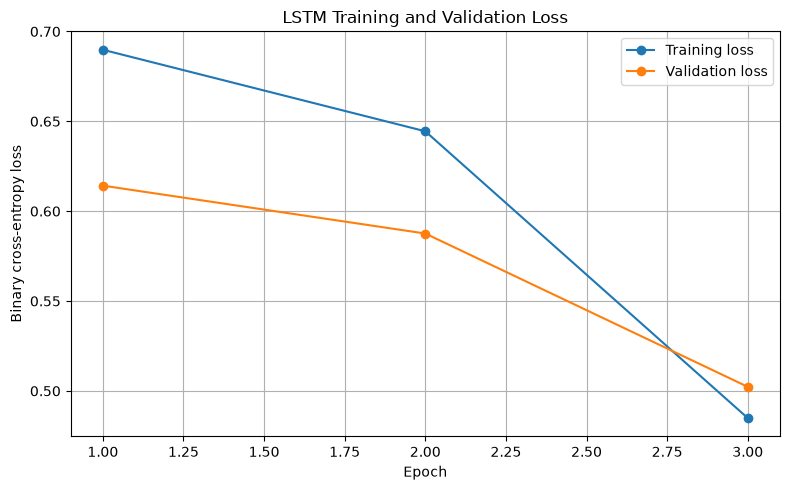

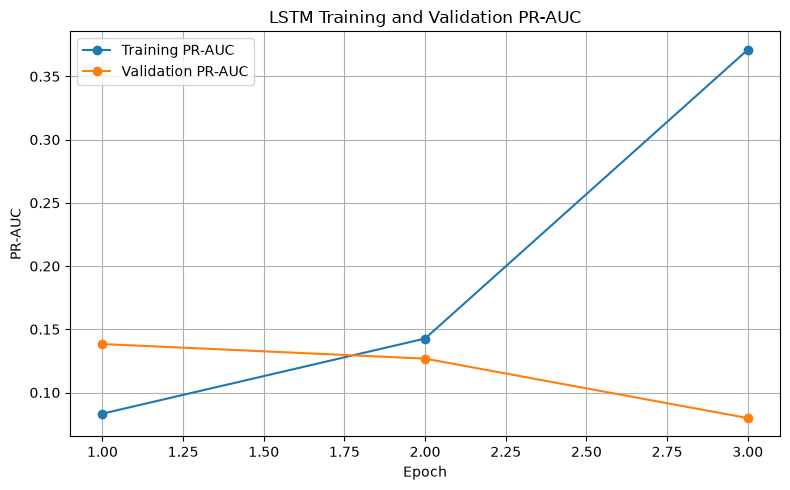

In [10]:
# Visualize LSTM training and validation performance.

history_df = pd.DataFrame(lstm_history.history)

print("Training history:")
print(history_df.round(4))

epochs_completed = range(
    1,
    len(history_df) + 1,
)

plt.figure(figsize=(8, 5))
plt.plot(
    epochs_completed,
    history_df["loss"],
    marker="o",
    label="Training loss",
)
plt.plot(
    epochs_completed,
    history_df["val_loss"],
    marker="o",
    label="Validation loss",
)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epochs_completed,
    history_df["pr_auc"],
    marker="o",
    label="Training PR-AUC",
)
plt.plot(
    epochs_completed,
    history_df["val_pr_auc"],
    marker="o",
    label="Validation PR-AUC",
)
plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("LSTM Training and Validation PR-AUC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
# Evaluate the restored LSTM model on validation data
# and select the best decision threshold using validation F1-score.

from sklearn.metrics import precision_recall_curve

print("Generating validation probabilities...")

validation_probabilities = lstm_model.predict(
    X_validation_padded,
    batch_size=BATCH_SIZE,
    verbose=1,
).ravel()

validation_average_precision = average_precision_score(
    y_validation_array,
    validation_probabilities,
)

validation_roc_auc = roc_auc_score(
    y_validation_array,
    validation_probabilities,
)

precision_values, recall_values, threshold_values = precision_recall_curve(
    y_validation_array,
    validation_probabilities,
)

# The final precision and recall values do not have a matching threshold.
threshold_precision = precision_values[:-1]
threshold_recall = recall_values[:-1]

threshold_f1 = np.divide(
    2 * threshold_precision * threshold_recall,
    threshold_precision + threshold_recall,
    out=np.zeros_like(threshold_precision),
    where=(threshold_precision + threshold_recall) != 0,
)

best_threshold_index = np.argmax(threshold_f1)

best_lstm_threshold = threshold_values[best_threshold_index]
best_lstm_precision = threshold_precision[best_threshold_index]
best_lstm_recall = threshold_recall[best_threshold_index]
best_lstm_f1 = threshold_f1[best_threshold_index]

optimized_validation_predictions = (
    validation_probabilities >= best_lstm_threshold
).astype(int)

optimized_validation_accuracy = accuracy_score(
    y_validation_array,
    optimized_validation_predictions,
)

optimized_validation_cm = confusion_matrix(
    y_validation_array,
    optimized_validation_predictions,
)

print("\nLSTM validation threshold tuning completed successfully.")

print(f"\nBest decision threshold: {best_lstm_threshold:.4f}")
print(f"Accuracy: {optimized_validation_accuracy:.4f}")
print(f"Precision: {best_lstm_precision:.4f}")
print(f"Recall: {best_lstm_recall:.4f}")
print(f"F1-score: {best_lstm_f1:.4f}")
print(f"Average precision: {validation_average_precision:.4f}")
print(f"ROC-AUC: {validation_roc_auc:.4f}")

print("\nOptimized validation confusion matrix:")
print(optimized_validation_cm)

Generating validation probabilities...
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step

LSTM validation threshold tuning completed successfully.

Best decision threshold: 0.4815
Accuracy: 0.8627
Precision: 0.1695
Recall: 0.3371
F1-score: 0.2256
Average precision: 0.1471
ROC-AUC: 0.6653

Optimized validation confusion matrix:
[[1264  147]
 [  59   30]]


In [12]:
# Evaluate the finalized LSTM model on the untouched test set.
# The validation-selected threshold is used without further adjustment.

print("Generating test probabilities...")

test_probabilities = lstm_model.predict(
    X_test_padded,
    batch_size=BATCH_SIZE,
    verbose=1,
).ravel()

optimized_test_predictions = (
    test_probabilities >= best_lstm_threshold
).astype(int)

test_accuracy = accuracy_score(
    y_test_array,
    optimized_test_predictions,
)

test_precision = precision_score(
    y_test_array,
    optimized_test_predictions,
    zero_division=0,
)

test_recall = recall_score(
    y_test_array,
    optimized_test_predictions,
    zero_division=0,
)

test_f1 = f1_score(
    y_test_array,
    optimized_test_predictions,
    zero_division=0,
)

test_average_precision = average_precision_score(
    y_test_array,
    test_probabilities,
)

test_roc_auc = roc_auc_score(
    y_test_array,
    test_probabilities,
)

optimized_test_cm = confusion_matrix(
    y_test_array,
    optimized_test_predictions,
)

print("\nFinal LSTM test evaluation completed successfully.")

print(f"\nSelected decision threshold: {best_lstm_threshold:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"Average precision: {test_average_precision:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")

print("\nDetailed test classification report:")
print(
    classification_report(
        y_test_array,
        optimized_test_predictions,
        target_names=[
            "Non-vulnerable",
            "Vulnerable",
        ],
        zero_division=0,
    )
)

print("\nOptimized test confusion matrix:")
print(optimized_test_cm)

Generating test probabilities...
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step

Final LSTM test evaluation completed successfully.

Selected decision threshold: 0.4815
Accuracy: 0.8620
Precision: 0.1520
Recall: 0.2955
F1-score: 0.2008
Average precision: 0.1097
ROC-AUC: 0.6220

Detailed test classification report:
                precision    recall  f1-score   support

Non-vulnerable       0.95      0.90      0.92      1412
    Vulnerable       0.15      0.30      0.20        88

      accuracy                           0.86      1500
     macro avg       0.55      0.60      0.56      1500
  weighted avg       0.91      0.86      0.88      1500


Optimized test confusion matrix:
[[1267  145]
 [  62   26]]


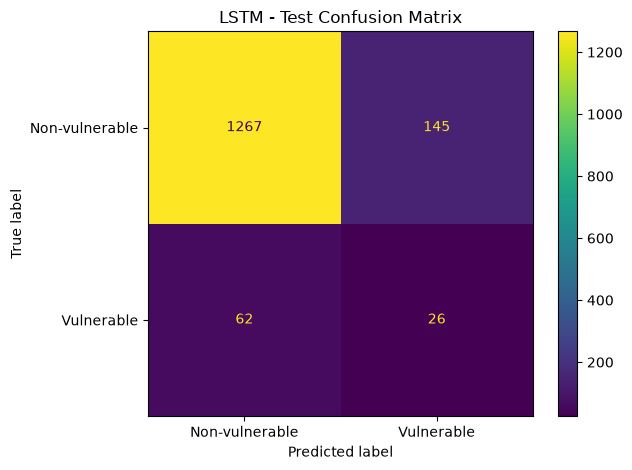

In [13]:
# Display the final LSTM test confusion matrix.

ConfusionMatrixDisplay(
    confusion_matrix=optimized_test_cm,
    display_labels=[
        "Non-vulnerable",
        "Vulnerable",
    ],
).plot(
    values_format="d",
)

plt.title("LSTM - Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [14]:
# Save the trained LSTM model, preprocessing artifacts,
# selected threshold and evaluation results.

import json
import joblib

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

LSTM_MODEL_PATH = (
    MODELS_DIR
    / "CIT-24-01-0251_lstm_model.keras"
)

PREPROCESSING_PATH = (
    MODELS_DIR
    / "CIT-24-01-0251_lstm_preprocessing.joblib"
)

METRICS_PATH = (
    REPORTS_DIR
    / "CIT-24-01-0251_lstm_metrics.json"
)

# Save the trained neural-network model.
lstm_model.save(
    str(LSTM_MODEL_PATH)
)

# Save everything required to prepare new source-code inputs.
lstm_preprocessing_bundle = {
    "tokenizer": lstm_tokenizer,
    "maximum_vocabulary_size": int(MAX_VOCAB_SIZE),
    "vocabulary_size_used": int(VOCAB_SIZE),
    "maximum_sequence_length": int(MAX_SEQUENCE_LENGTH),
    "decision_threshold": float(best_lstm_threshold),
    "class_labels": {
        0: "Non-vulnerable",
        1: "Vulnerable",
    },
}

joblib.dump(
    lstm_preprocessing_bundle,
    PREPROCESSING_PATH,
)

best_validation_epoch = int(
    np.argmax(history_df["val_pr_auc"].to_numpy()) + 1
)

lstm_metrics = {
    "student_id": "CIT-24-01-0251",
    "model": "Long Short-Term Memory Network",
    "input_representation": "Code-token integer sequences",
    "dataset_size": int(len(lstm_df)),
    "training_records": int(len(X_train)),
    "validation_records": int(len(X_validation)),
    "testing_records": int(len(X_test)),
    "vocabulary_size": int(VOCAB_SIZE),
    "maximum_sequence_length": int(MAX_SEQUENCE_LENGTH),
    "embedding_dimension": int(EMBEDDING_DIM),
    "lstm_units": int(LSTM_UNITS),
    "total_parameters": int(lstm_model.count_params()),
    "epochs_completed": int(
        len(lstm_history.history["loss"])
    ),
    "best_validation_epoch": best_validation_epoch,
    "decision_threshold": float(best_lstm_threshold),
    "validation_metrics": {
        "accuracy": float(optimized_validation_accuracy),
        "precision": float(best_lstm_precision),
        "recall": float(best_lstm_recall),
        "f1_score": float(best_lstm_f1),
        "average_precision": float(
            validation_average_precision
        ),
        "roc_auc": float(validation_roc_auc),
        "confusion_matrix": optimized_validation_cm.tolist(),
    },
    "test_metrics": {
        "accuracy": float(test_accuracy),
        "precision": float(test_precision),
        "recall": float(test_recall),
        "f1_score": float(test_f1),
        "average_precision": float(test_average_precision),
        "roc_auc": float(test_roc_auc),
        "confusion_matrix": optimized_test_cm.tolist(),
    },
    "training_history": {
        metric: [
            float(value)
            for value in values
        ]
        for metric, values in lstm_history.history.items()
    },
}

with open(
    METRICS_PATH,
    "w",
    encoding="utf-8",
) as metrics_file:
    json.dump(
        lstm_metrics,
        metrics_file,
        indent=4,
    )

print("LSTM artifacts saved successfully.")

print("\nLSTM model:")
print(LSTM_MODEL_PATH)
print("Model exists:", LSTM_MODEL_PATH.exists())

print("\nPreprocessing bundle:")
print(PREPROCESSING_PATH)
print(
    "Preprocessing bundle exists:",
    PREPROCESSING_PATH.exists(),
)

print("\nMetrics report:")
print(METRICS_PATH)
print("Metrics report exists:", METRICS_PATH.exists())

LSTM artifacts saved successfully.

LSTM model:
f:\BSc (Hons) in Cyber Security\Projects\NLP_Group_02\models\CIT-24-01-0251_lstm_model.keras
Model exists: True

Preprocessing bundle:
f:\BSc (Hons) in Cyber Security\Projects\NLP_Group_02\models\CIT-24-01-0251_lstm_preprocessing.joblib
Preprocessing bundle exists: True

Metrics report:
f:\BSc (Hons) in Cyber Security\Projects\NLP_Group_02\reports\CIT-24-01-0251_lstm_metrics.json
Metrics report exists: True
